## Dataset Overview

In [1]:
import pandas as pd

df = pd.read_excel("../data/ApexPlanet_DataAnalytics_Dataset.xlsx")
df.shape

(1000, 12)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   str    
 1   Order_Date     1000 non-null   str    
 2   Customer_ID    1000 non-null   str    
 3   Customer_Name  1000 non-null   str    
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   str    
 6   City           987 non-null    str    
 7   Product        1000 non-null   str    
 8   Category       1000 non-null   str    
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), str(8)
memory usage: 93.9 KB


### Observation

The dataset contains 1000 records and 12 variables related to retail sales transactions.

The dataset includes customer demographics, product details, and transaction information. Most columns are categorical, while Age, Quantity, Unit_Price, and Total_Sales are numerical variables.

The Order_Date column is currently stored as a string and will require conversion to datetime format for time-based analysis.

## Descriptive Statistics

In [8]:
df.describe()

,Age,Quantity,Unit_Price,Total_Sales
count,980.000000,1000.000000,1000.000000,1000.000000
mean,41.360204,5.435000,25486.783410,139399.439650
std,13.822597,2.838632,14179.402361,114100.051546
min,18.000000,1.000000,145.780000,437.340000
25%,30.000000,3.000000,13895.722500,47066.632500
50%,41.000000,5.000000,25398.740000,108594.025000
75%,54.000000,8.000000,37512.382500,203722.882500
max,65.000000,10.000000,49997.530000,493677.500000


### Observation

The average customer age is approximately 41 years, with ages ranging from 18 to 65 years.

Customers purchase around 5 to 6 units per transaction on average.

The mean Total_Sales value (₹139,399) is higher than the median value (₹108,594), suggesting the presence of high-value transactions that may influence the overall sales distribution.

Further exploratory analysis will be performed to identify sales patterns and potential outliers.

## Data Quality Assessment

In [4]:
df.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Customer_Name     0
Age              20
Gender            0
City             13
Product           0
Category          0
Quantity          0
Unit_Price        0
Total_Sales       0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

### Observation

Missing values were detected in the Age (20 records) and City (13 records) columns.

No duplicate records were found in the dataset, indicating good data consistency.

The amount of missing data is relatively small and can be handled during the data preparation stage.

## Date Format Conversion

In [9]:
df['Order_Date'].head()

0    2025-02-25
1    2025-10-14
2    2025-05-13
3    2025-12-02
4    2025-11-20
Name: Order_Date, dtype: str

In [10]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Order_Date'].dtype

dtype('<M8[us]')

The Order_Date column was converted from string format to datetime format to enable time-based analysis such as monthly trends and seasonal sales patterns.

## Handling Missing Values in Age

The Age column contains 20 missing values.

Since age is a numerical variable and may contain extreme values, the median was chosen instead of the mean for imputation. Median is less sensitive to outliers and provides a more robust estimate of the central tendency.

In [15]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Age'].isnull().sum()

np.int64(0)

### Observation

All missing values in the Age column were successfully handled using median imputation.

The dataset now contains complete age information while preserving the overall distribution of the variable.

## Handling Missing Values in City

The City column contains 13 missing values.

Since City is a categorical variable and no single city dominates the dataset, replacing missing values with the mode could introduce bias.

Therefore, missing values were replaced with the label "Unknown" to preserve the records while maintaining data integrity.

In [17]:
df['City'].value_counts().head()

City
Patna        135
Kolkata      133
Mumbai       131
Hyderabad    125
Delhi        125
Name: count, dtype: int64

In [19]:
df['City'] = df['City'].fillna('Unknown')
df['City'].isnull().sum()

np.int64(0)

### Observation

All missing values in the City column were successfully handled by assigning the category "Unknown".

This approach avoids introducing assumptions about customer locations and preserves the original dataset size.

## Data Validation

In [23]:
df['Calculated_Sales'] = df['Quantity'] * df['Unit_Price']
(df['Calculated_Sales'] == df['Total_Sales']).sum()

np.int64(822)

In [24]:
len(df)

1000

In [25]:
df[
    df['Calculated_Sales'] != df['Total_Sales']
][[
    'Quantity',
    'Unit_Price',
    'Calculated_Sales',
    'Total_Sales'
]].head(10)

,Quantity,Unit_Price,Calculated_Sales,Total_Sales
7,3,9488.83,28466.49,28466.49
21,7,15396.37,107774.59,107774.59
24,7,36069.86,252489.02,252489.02
27,5,14534.79,72673.95,72673.95
32,5,17556.08,87780.40,87780.40
33,5,46822.84,234114.20,234114.20
42,6,16521.44,99128.64,99128.64
44,9,1491.63,13424.67,13424.67
51,6,4656.10,27936.60,27936.60
58,5,36809.08,184045.40,184045.40


In [26]:
import numpy as np

np.isclose(
    df['Calculated_Sales'],
    df['Total_Sales']
).sum()

np.int64(1000)

### Observation

A validation check was performed to verify whether Total_Sales equals Quantity × Unit_Price.

Direct equality comparison showed minor mismatches due to floating-point precision. A tolerance-based comparison using NumPy's isclose() function confirmed that all 1000 records satisfy the sales calculation rule.

The dataset passed the validation check successfully.

## Feature Engineering

In [27]:
df['Month'] = df['Order_Date'].dt.month_name()
df[['Order_Date', 'Month']].head()

,Order_Date,Month
0,2025-02-25,February
1,2025-10-14,October
2,2025-05-13,May
3,2025-12-02,December
4,2025-11-20,November


A Month column was extracted from Order_Date to support monthly sales analysis and business trend identification.

## Feature Engineering: Age Groups

Customer ages were grouped into meaningful categories to simplify demographic analysis.

Creating age groups enables easier comparison of purchasing behavior across different customer segments and supports business-oriented insights.

In [28]:
bins = [18, 25, 35, 45, 55, 65]

labels = [
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '56-65'
]

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [29]:
df[['Age', 'Age_Group']].head()
df['Age_Group'].value_counts()

Age_Group
36-45    223
26-35    219
46-55    202
56-65    198
18-25    158
Name: count, dtype: int64

### Observation

Customers are fairly distributed across different age groups, with the highest representation in the 36–45 and 26–35 segments.

The balanced distribution of age groups indicates that the dataset represents a diverse customer base, making it suitable for demographic and behavioral analysis.

The 18–25 age group has comparatively fewer customers, while the remaining age segments are distributed relatively evenly.

# Univariate Analysis

## Age Distribution

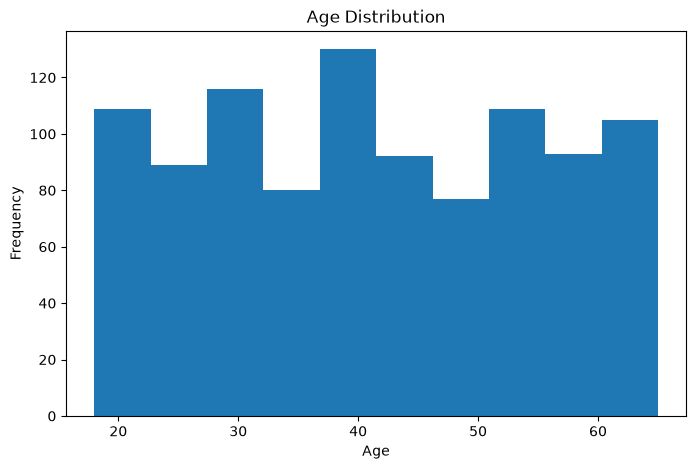

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=10)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Observation

The age distribution appears relatively balanced across the customer base, with no significant skewness or extreme concentration in a particular age range.

A slightly higher concentration of customers is observed around the 36–45 age segment, which aligns with the age-group analysis performed earlier.

No major outliers are visible, indicating that customer ages are reasonably distributed throughout the dataset.

### Business Insight

The customer base is diverse and spans multiple age groups rather than being dominated by a single demographic segment.

The strong representation of customers between 26 and 55 years suggests that marketing campaigns and product strategies should primarily target working-age consumers while still considering the needs of younger and older customer segments.

### Why It Matters

Understanding customer age distribution helps businesses identify their primary target audience and design age-specific marketing, pricing, and promotional strategies.

A balanced age distribution also enables meaningful customer segmentation and demographic analysis in later stages of the project.

## Customer Distribution by Age Group

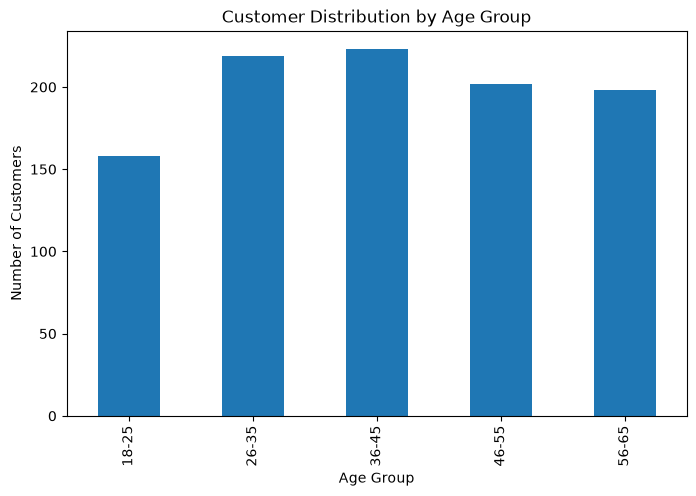

In [32]:
plt.figure(figsize=(8,5))
df['Age_Group'].value_counts().sort_index().plot(kind='bar')
plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()

### Reasoning

The Age_Group feature was visualized to examine customer distribution across different demographic segments.

Grouping customers into age categories provides a clearer business perspective than individual age values and supports customer segmentation analysis.

### Observation

The 36–45 and 26–35 age groups contain the highest number of customers, while the 18–25 segment has the lowest representation.

Customer counts are relatively balanced across the remaining age groups, indicating a diverse customer population.

### Business Insight

Middle-aged and working-age customers form the largest portion of the customer base.

These segments may contribute significantly to sales and should be prioritized when designing marketing campaigns, loyalty programs, and product recommendations.

### Why It Matters

Age-group segmentation enables businesses to better understand customer demographics and identify high-value target audiences.

This information can be used to create personalized marketing strategies and improve customer engagement.

## Quantity Distribution

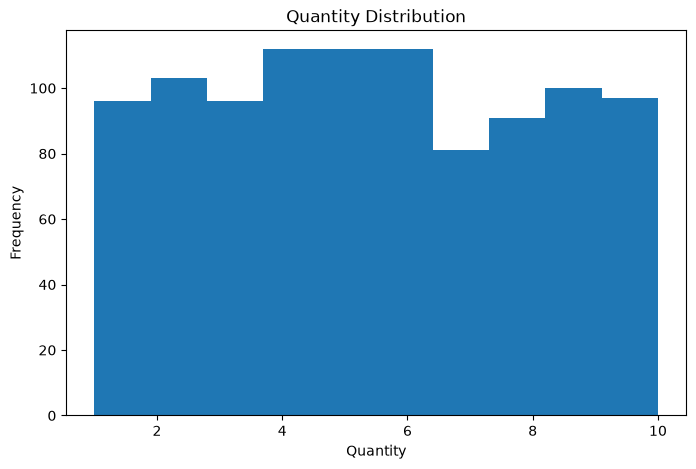

In [33]:
plt.figure(figsize=(8,5))
plt.hist(df['Quantity'], bins=10)
plt.title('Quantity Distribution')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

### Reasoning

The Quantity variable was analyzed to understand customer purchasing behavior and identify common order sizes.

Studying quantity distribution helps reveal whether customers typically purchase small, medium, or large numbers of products per transaction.

### Observation

The quantity distribution is relatively balanced across the available range of values (1–10).

Most transactions involve purchasing around 4–6 units, which is consistent with the average quantity observed in the descriptive statistics.

No significant skewness or extreme purchasing patterns are visible in the dataset.

### Business Insight

Customers generally purchase moderate quantities rather than consistently placing very small or very large orders.

This indicates stable purchasing behavior and suggests that product demand is distributed across a variety of order sizes.

### Why It Matters

Understanding order quantities helps businesses estimate inventory requirements, forecast demand, and optimize stock management.

It also provides insights into customer purchasing behavior and average order volume.

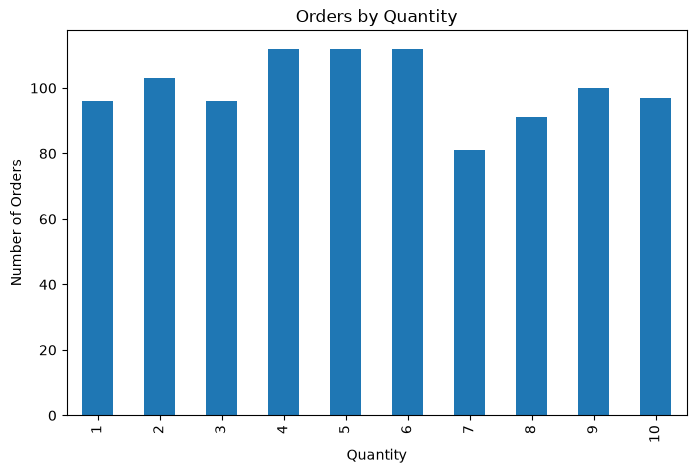

In [34]:
plt.figure(figsize=(8,5))
df['Quantity'].value_counts().sort_index().plot(kind='bar')
plt.title('Orders by Quantity')
plt.xlabel('Quantity')
plt.ylabel('Number of Orders')
plt.show()

### Observation

Order quantities are distributed relatively evenly across the dataset, with quantities 4, 5, and 6 occurring most frequently.

Quantity 7 appears less common than the surrounding order sizes, while the remaining quantities show similar order frequencies.

The distribution does not indicate any strong bias toward either very small or very large orders.

### Business Insight

Most customers tend to place medium-sized orders rather than consistently purchasing only a few items or making bulk purchases.

This suggests stable purchasing behavior and indicates that demand is spread across multiple order sizes rather than concentrated in a specific quantity segment.

### Why It Matters

Understanding order-size patterns helps businesses optimize inventory planning, demand forecasting, and promotional strategies.

It also provides insights into customer purchasing habits and average basket size.

## Total Sales Distribution

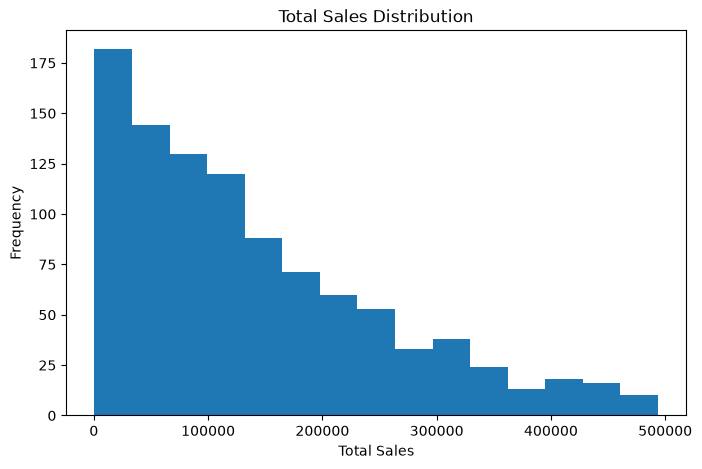

In [35]:
plt.figure(figsize=(8,5))
plt.hist(df['Total_Sales'], bins=15)
plt.title('Total Sales Distribution')
plt.xlabel('Total Sales')
plt.ylabel('Frequency')
plt.show()

### Observation

The Total_Sales distribution is positively skewed, with a large number of transactions occurring in the lower and medium sales ranges.

As sales values increase, the number of transactions gradually decreases, indicating that high-value transactions are less frequent.

A small number of orders contribute exceptionally high sales values compared to the majority of transactions.

### Business Insight

Most customers generate low-to-moderate sales per transaction, while a smaller group of customers contributes high-value purchases.

This suggests the presence of potentially high-value customers whose purchasing behavior may significantly impact overall revenue.

### Why It Matters

Understanding sales distribution helps businesses identify revenue patterns, customer spending behavior, and the contribution of high-value transactions.

Such insights can support targeted marketing campaigns, premium customer programs, and revenue optimization strategies.

## Total Sales Box Plot

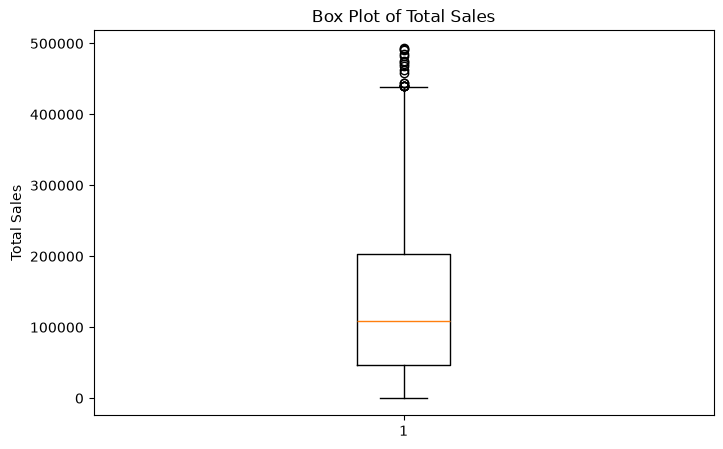

In [36]:
plt.figure(figsize=(8,5))
plt.boxplot(df['Total_Sales'])
plt.title('Box Plot of Total Sales')
plt.ylabel('Total Sales')
plt.show()

### Reasoning

A box plot was created to examine the spread of sales values and identify potential outliers.

This visualization provides a summary of the distribution, including the median, quartiles, and unusually high or low sales transactions.

### Observation

The box plot confirms that Total_Sales is positively skewed and contains several high-value outliers.

Most transactions fall within a moderate sales range, while a small number of orders exhibit exceptionally high sales values.

The median sales value is positioned closer to the lower half of the distribution, further indicating the presence of high-value transactions.

### Business Insight

A small number of high-value transactions contribute significantly to overall revenue.

These transactions may represent premium customers or large purchases and could be valuable targets for customer retention and loyalty initiatives.

## Category Distribution

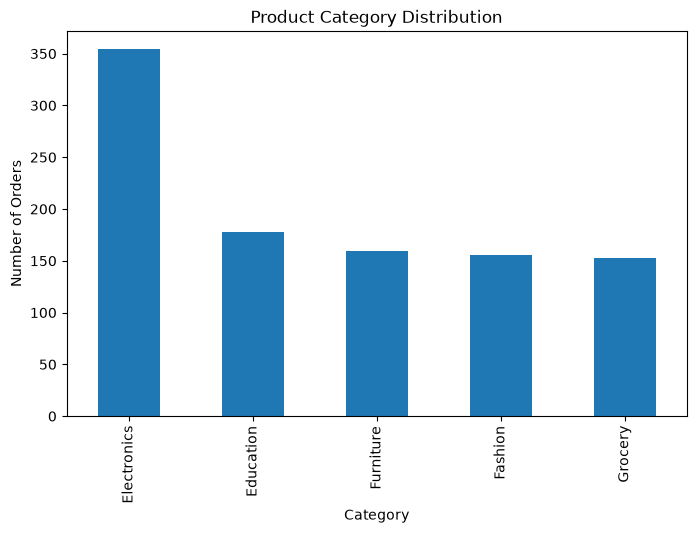

In [37]:
plt.figure(figsize=(8,5))
df['Category'].value_counts().plot(kind='bar')
plt.title('Product Category Distribution')
plt.xlabel('Category')
plt.ylabel('Number of Orders')
plt.show()

### Reasoning

The Category variable was analyzed to understand how customer purchases are distributed across different product categories.

Identifying popular categories helps businesses understand customer preferences and product demand patterns.

### Observation

Electronics is the most frequently purchased category, accounting for a significantly higher number of orders than all other categories.

The remaining categories—Education, Furniture, Fashion, and Grocery—show relatively similar order volumes, indicating a balanced distribution among non-electronics products.

### Business Insight

Customer demand appears to be strongly concentrated in the Electronics category.

This suggests that electronic products are a major driver of customer purchases and may represent a key area for inventory planning, marketing campaigns, and revenue generation.

### Why It Matters

Understanding category popularity helps businesses allocate inventory efficiently, identify high-demand product segments, and prioritize promotional activities.

Categories with consistently high demand can be leveraged to attract customers and increase overall sales performance.

## Total Sales by Category

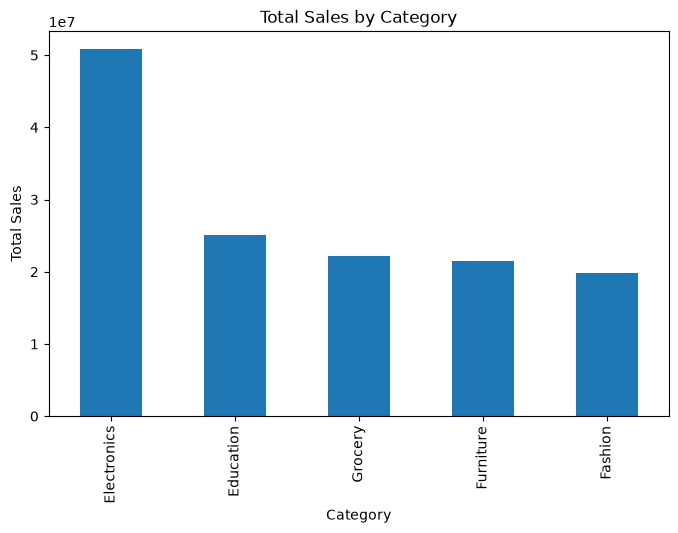

In [38]:
category_sales = df.groupby('Category')['Total_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

In [39]:
category_sales

Category
Electronics    50778581.70
Education      25031689.40
Grocery        22231711.28
Furniture      21521561.48
Fashion        19835895.79
Name: Total_Sales, dtype: float64

### Observation

Electronics generated the highest total sales, contributing more than twice the revenue of several other categories.

Education ranked second in total sales, followed by Grocery and Furniture, while Fashion generated the lowest revenue among all categories.

The sales distribution indicates a strong concentration of revenue within the Electronics category.

### Business Insight

Electronics is the primary revenue-driving category and represents a significant contributor to overall business performance.

The combination of high order volume and high revenue suggests strong customer demand and purchasing value within this category.

Businesses may benefit from prioritizing inventory availability, targeted promotions, and customer retention strategies for electronics products.

### Why It Matters

Identifying high-revenue categories enables businesses to focus resources on the most profitable product segments.

Category-level revenue analysis supports inventory planning, marketing investment decisions, and long-term growth strategies.

## Average Sales per Category

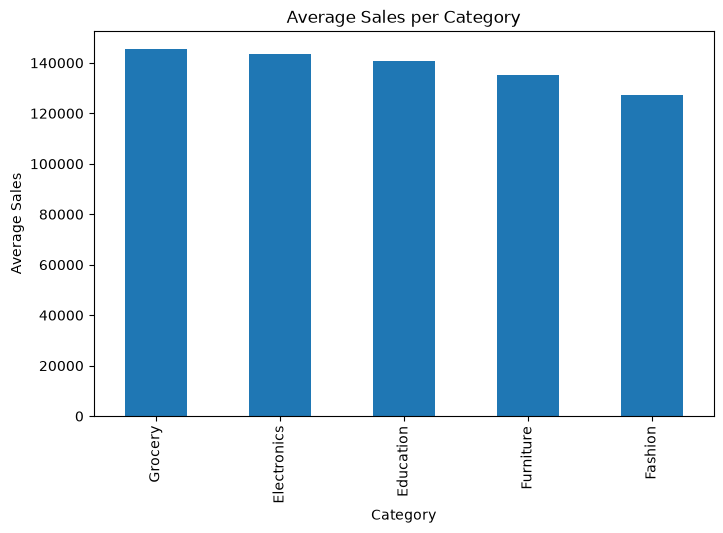

Category
Grocery        145305.302484
Electronics    143442.321186
Education      140627.468539
Furniture      135355.732579
Fashion        127153.178141
Name: Total_Sales, dtype: float64

In [40]:
avg_sales = df.groupby('Category')['Total_Sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
avg_sales.plot(kind='bar')
plt.title('Average Sales per Category')
plt.xlabel('Category')
plt.ylabel('Average Sales')
plt.show()

avg_sales

### Observation

The average sales value across categories is relatively similar, ranging from approximately 127,000 to 145,000.

Grocery has the highest average sales per transaction, followed closely by Electronics and Education.

Fashion records the lowest average sales value among all categories.

### Business Insight

Although Electronics generates the highest total revenue, Grocery achieves the highest average sales per transaction.

This suggests that Grocery purchases tend to have higher transaction values, while Electronics benefits from a larger volume of orders.

Businesses can use this information to design category-specific sales and marketing strategies.

### Why It Matters

Average sales analysis helps distinguish between revenue generated through high order volume and revenue generated through high transaction value.

This enables businesses to identify categories that drive customer spending and optimize pricing, promotions, and inventory strategies accordingly.

## Monthly Sales Trend

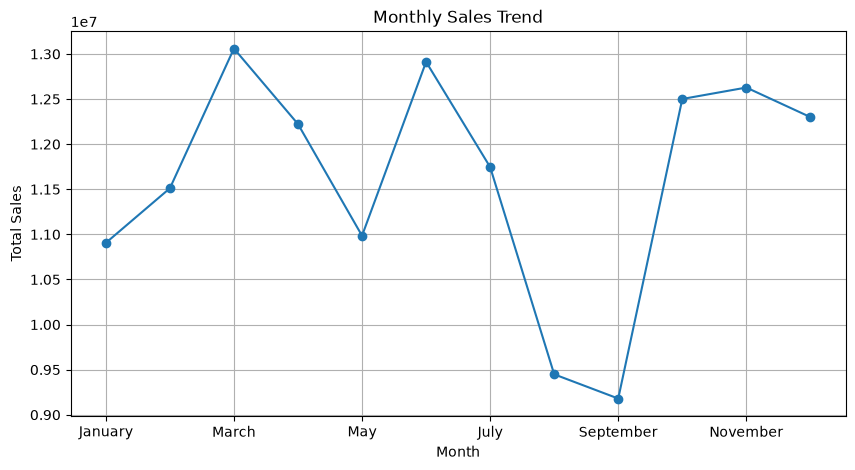

In [41]:
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

### Reasoning

Monthly sales trends were analyzed to understand how revenue changes over time and to identify periods of high and low business performance.

Time-based analysis helps businesses detect seasonal patterns, sales fluctuations, and opportunities for strategic planning.

### Observation

Sales fluctuate throughout the year rather than remaining constant.

March records the highest sales performance, while September shows the lowest revenue level.

A significant decline is observed during August and September, followed by a strong recovery in October and continued strong performance through the final months of the year.

### Business Insight

The business experiences periods of both strong and weak sales activity.

The sharp increase in sales after September suggests that certain months may benefit from higher customer demand, seasonal purchasing behavior, or promotional activities.

Understanding these trends can help businesses prepare inventory and marketing campaigns during peak periods while addressing revenue slowdowns during weaker months.

### Why It Matters

Monthly trend analysis helps organizations forecast demand, optimize inventory levels, and allocate resources effectively.

Identifying peak and low-performing months enables data-driven planning and improves overall business decision-making.

## Monthly Sales Heatmap by Category

In [42]:
category_monthly = df.pivot_table(
    values='Total_Sales',
    index='Month',
    columns='Category',
    aggfunc='sum'
)

In [43]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

category_monthly = category_monthly.reindex(month_order)

In [44]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

category_monthly = category_monthly.reindex(month_order)

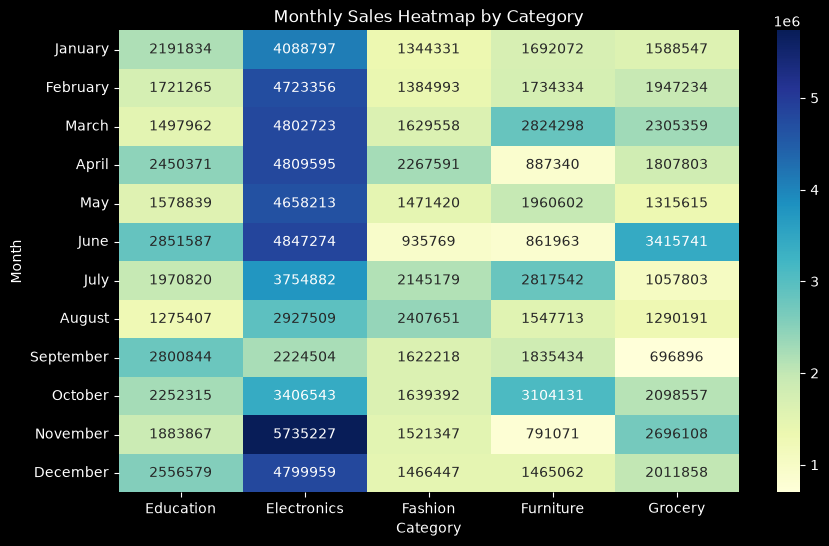

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    category_monthly,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title('Monthly Sales Heatmap by Category')
plt.xlabel('Category')
plt.ylabel('Month')
plt.show()

### Reasoning

A heatmap was created to visualize sales performance across product categories and months simultaneously.

This visualization helps identify seasonal trends, high-performing periods, and category-specific sales patterns that may not be visible in individual charts.

### Observation

Electronics consistently records the highest sales across most months, indicating strong and sustained customer demand.

November shows the highest sales value in the dataset, particularly within the Electronics category.

Certain categories such as Furniture and Grocery exhibit noticeable fluctuations across months, while Electronics maintains relatively strong performance throughout the year.

### Business Insight

Electronics represents the most important revenue-generating category and should remain a strategic business focus.

The strong sales performance observed during specific months, particularly November, suggests the presence of seasonal demand patterns that can be leveraged through targeted promotions and inventory planning.

Categories with fluctuating sales may benefit from category-specific marketing campaigns during weaker months.

### Why It Matters

Heatmaps allow businesses to analyze multiple dimensions simultaneously and identify patterns that may not be visible in individual charts.

Such insights support demand forecasting, inventory optimization, and data-driven decision-making.

## Top 10 Customers by Revenue

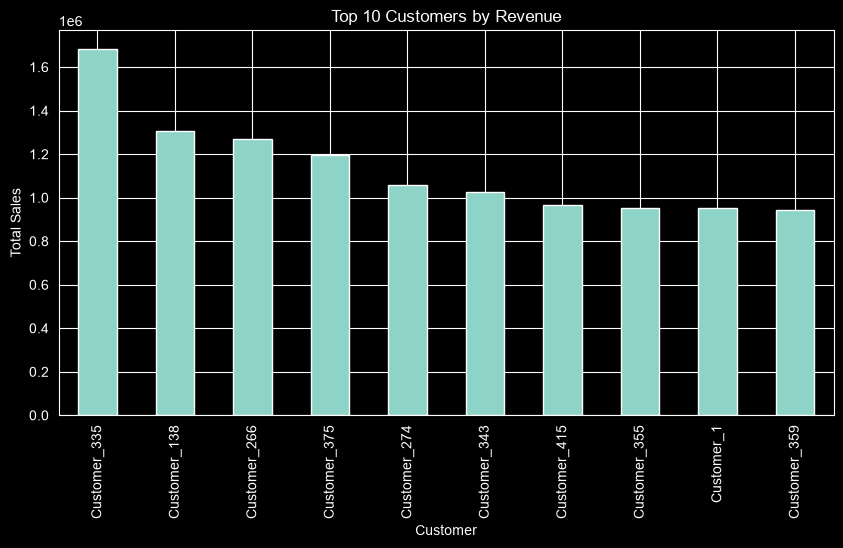

Customer_Name
Customer_335    1684832.52
Customer_138    1305932.64
Customer_266    1269445.22
Customer_375    1196934.33
Customer_274    1060340.15
Customer_343    1025447.16
Customer_415     967962.17
Customer_355     954513.58
Customer_1       952753.99
Customer_359     941957.21
Name: Total_Sales, dtype: float64

In [47]:
top_customers = (
    df.groupby('Customer_Name')['Total_Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
top_customers.plot(kind='bar')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer')
plt.ylabel('Total Sales')
plt.show()

top_customers

### Reasoning

Customer-level revenue analysis was performed to identify the highest-value customers and understand revenue concentration within the customer base.

Identifying top customers helps businesses develop targeted retention strategies and recognize customers who contribute significantly to overall sales.

### Observation

Customer_335 generated the highest revenue, contributing approximately 1.68 million in total sales.

The remaining top customers generated revenues ranging from approximately 0.95 million to 1.31 million, indicating that several customers contribute substantially to business revenue.

No single customer overwhelmingly dominates the dataset, suggesting that revenue is distributed across multiple high-value customers.

### Business Insight

A relatively small group of customers contributes a significant portion of total revenue.

These high-value customers may represent an important customer segment and could be prioritized through loyalty programs, personalized offers, and retention initiatives.

### Why It Matters

Understanding customer revenue contribution helps businesses focus on customer retention, increase customer lifetime value, and develop personalized marketing strategies for high-performing customer segments.

## Total Sales by Gender

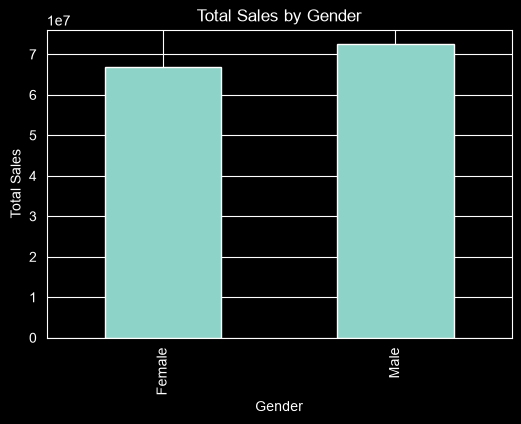

Gender
Female    66935889.02
Male      72463550.63
Name: Total_Sales, dtype: float64

In [48]:
gender_sales = df.groupby('Gender')['Total_Sales'].sum()

plt.figure(figsize=(6,4))
gender_sales.plot(kind='bar')
plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.show()

gender_sales

### Reasoning

Gender-based sales analysis was performed to understand revenue contribution across customer demographics.

This analysis helps identify purchasing patterns and potential differences in customer spending behavior between gender groups.

### Observation

Male customers generated approximately 72.46 million in total sales, while female customers generated approximately 66.94 million.

Although both groups contribute significantly to revenue, male customers account for a slightly higher share of total sales.

### Business Insight

The relatively balanced revenue contribution from both genders suggests that the business appeals to a broad customer base.

However, the higher sales generated by male customers may indicate stronger purchasing activity or higher transaction values within this segment.

### Why It Matters

Demographic analysis enables businesses to better understand customer segments and design targeted marketing strategies.

Insights into gender-based purchasing behavior can support customer engagement and promotional planning.